In [1]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout,BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Bidirectional


In [2]:
df = pd.read_csv("C:\\college\\machine learning\\deep learning\\lstm\\IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
print(df.shape)
print(df.columns)
print(df["sentiment"].value_counts())

(50000, 2)
Index(['review', 'sentiment'], dtype='object')
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [4]:
df["sentiment"]=df["sentiment"].map({"positive":1,"negative":0})
print(df["sentiment"].value_counts())

sentiment
1    25000
0    25000
Name: count, dtype: int64


In [5]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"[^a-zA-Z0-9' ]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [6]:
df["review"] = df["review"].fillna("").astype(str).apply(clean_text)
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,1
1,a wonderful little production the filming tech...,1
2,i thought this was a wonderful way to spend ti...,1
3,basically there's a family where a little boy ...,0
4,petter mattei's love in the time of money is a...,1


In [7]:
x=df["review"]
y=df["sentiment"]

In [8]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 40000
Test size: 10000


In [9]:
max_words = 20000
max_len = 200
tokenizer= Tokenizer(num_words=max_words,oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

In [10]:
x_train_seq=tokenizer.texts_to_sequences(X_train)
x_test_seq=tokenizer.texts_to_sequences(X_test)

In [11]:
x_train_pad = pad_sequences(x_train_seq, maxlen=max_len, padding="post", truncating="post")
x_test_pad = pad_sequences(x_test_seq, maxlen=max_len, padding="post", truncating="post")

print(x_train_pad.shape)
print(x_test_pad.shape)

(40000, 200)
(10000, 200)


In [12]:
model_lstm = Sequential([
    Embedding(max_words, 256, input_length=max_len),
    Bidirectional(LSTM(128, return_sequences=True)),
    BatchNormalization(),
    Dropout(0.5),
    Bidirectional(LSTM(64)),
    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])
model_lstm.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
model_lstm.summary()

c:\Users\arjb0\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=2,
    restore_best_weights=True
)

In [14]:
history_lstm = model_lstm.fit(
    x_train_pad,
    y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 397s 788ms/step - accuracy: 0.6874 - loss: 0.6049 - val_accuracy: 0.5056 - val_loss: 1.4976
Epoch 2/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 429s 858ms/step - accuracy: 0.8555 - loss: 0.3454 - val_accuracy: 0.8593 - val_loss: 0.3306
Epoch 3/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 450s 900ms/step - accuracy: 0.9018 - loss: 0.2546 - val_accuracy: 0.8666 - val_loss: 0.3288
Epoch 4/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 465s 929ms/step - accuracy: 0.9255 - loss: 0.2009 - val_accuracy: 0.8651 - val_loss: 0.3506
Epoch 5/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 477s 880ms/step - accuracy: 0.9401 - loss: 0.1665 - val_accuracy: 0.8674 - val_loss: 0.3486
Epoch 6/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 464s 927ms/step - accuracy: 0.9585 - loss: 0.1173 - val_accuracy: 0.8620 - val_loss: 0.3995
Epoch 7/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 482s 965ms/step - accuracy: 0.9557 - loss: 0.1247 - val_accuracy: 0.8555 - val_loss: 0.3929


In [18]:
loss, accuracy = model_lstm.evaluate(x_test_pad, y_test, verbose=1)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.8663 - loss: 0.3585
Test Loss: 0.3585
Test Accuracy: 0.8663


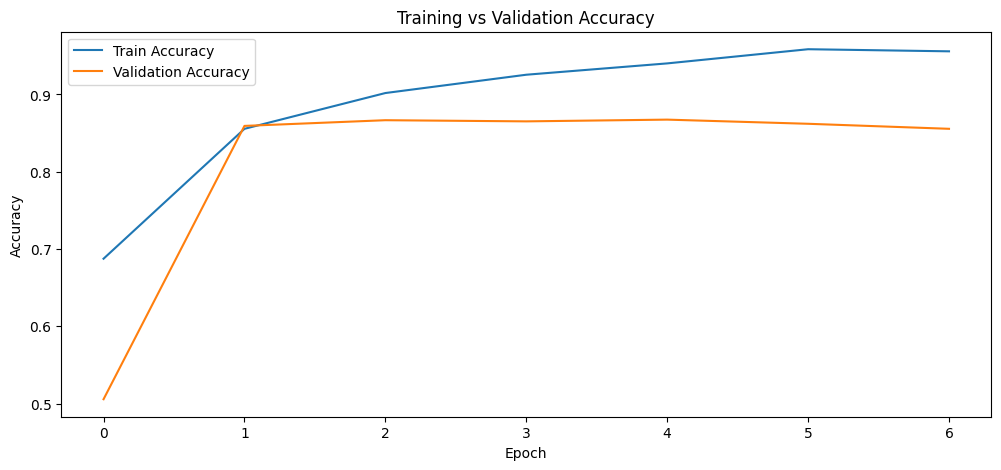

In [16]:
plt.figure(figsize=(12, 5))
plt.plot(history_lstm.history["accuracy"], label="Train Accuracy")
plt.plot(history_lstm.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

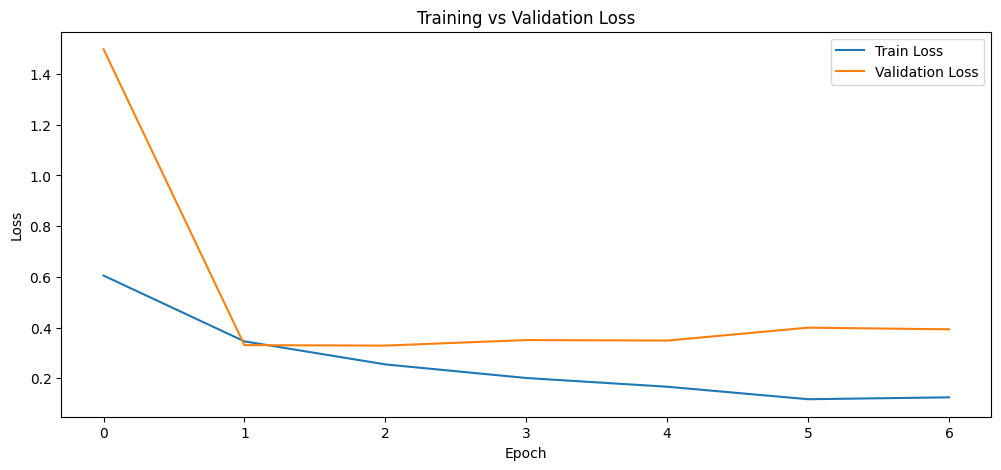

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(history_lstm.history["loss"], label="Train Loss")
plt.plot(history_lstm.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()